In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_openml
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

In [2]:
mnist = fetch_openml('mnist_784', as_frame=True)
print(type(mnist))

<class 'sklearn.utils._bunch.Bunch'>


In [3]:
print(mnist.keys())

dict_keys(['data', 'target', 'frame', 'categories', 'feature_names', 'target_names', 'DESCR', 'details', 'url'])


In [53]:
data = mnist['data']
target = mnist['target']

print(type(data))
print(type(target))

<class 'pandas.DataFrame'>
<class 'pandas.Series'>


In [54]:
print(data.shape)

(70000, 784)


In [55]:
print(target.shape)
target.describe()

(70000,)


count     70000
unique       10
top           1
freq       7877
Name: class, dtype: object

In [56]:
X, y = data.to_numpy(dtype=int), target.to_numpy(dtype=int)

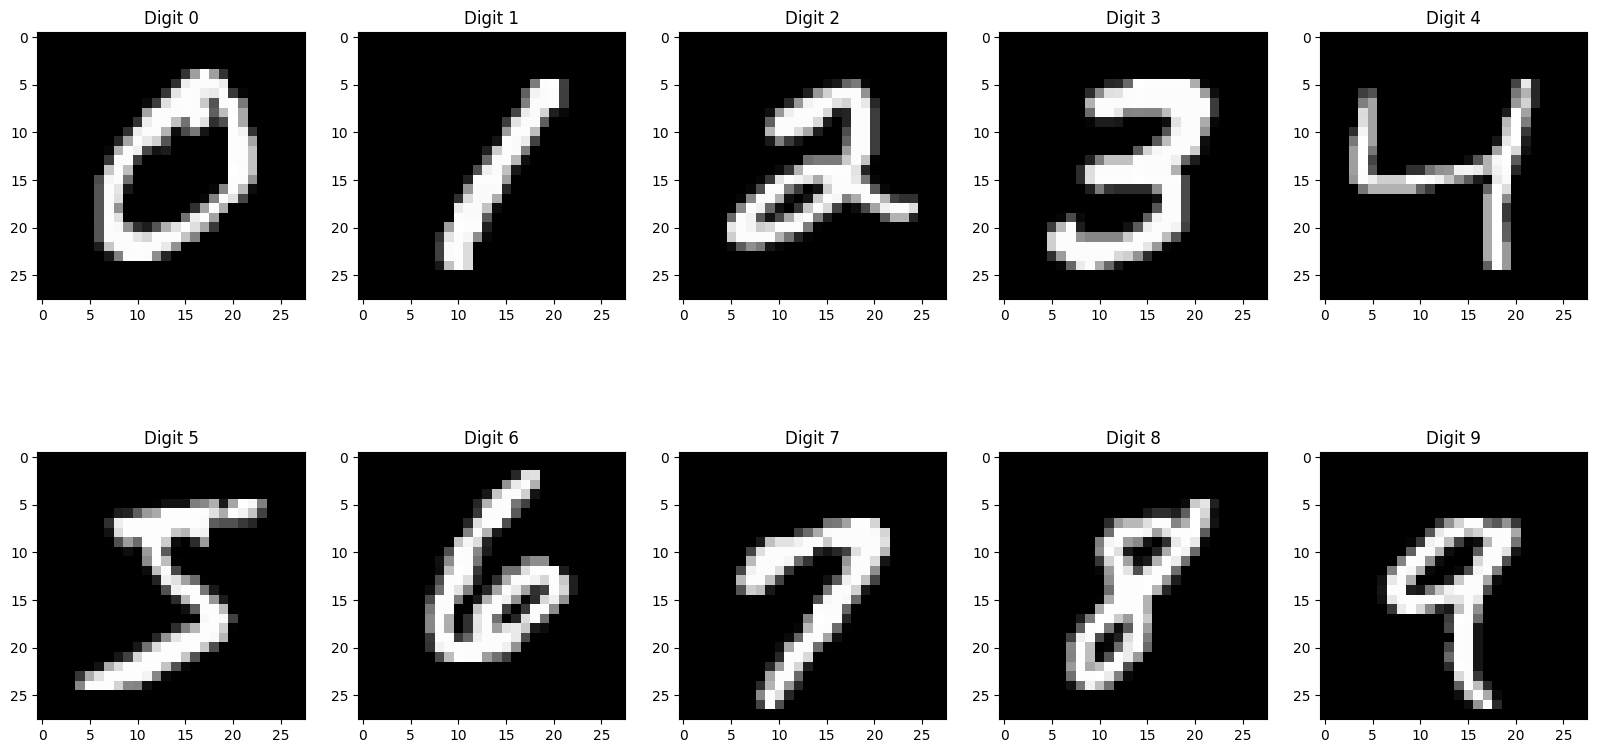

In [57]:
plt.figure(figsize=(20, 10))
for i in range(10):
    plt.subplot(2, 5, i+1)
    image = X[y == i][0].reshape(28, 28)
    plt.imshow(image, cmap="gray")
    plt.title(f"Digit {i}")

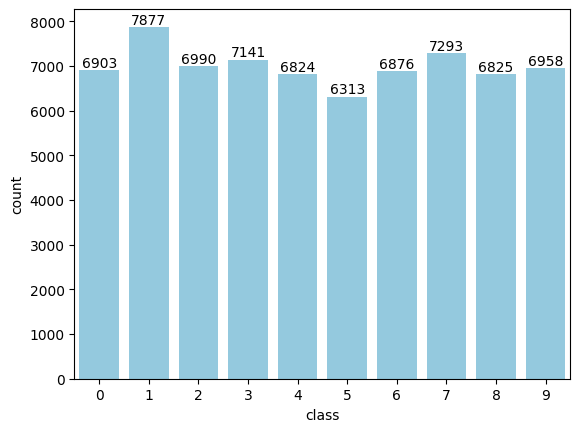

In [58]:
ax = sns.countplot(x=target, color='skyblue')
for container in ax.containers:
    ax.bar_label(container)

In [59]:
print(min(data.min()))
print(max(data.max()))

0
255


In [60]:
from sklearn.preprocessing import MinMaxScaler

In [61]:
scaler = MinMaxScaler()

In [62]:
X_scaled = scaler.fit_transform(X)
print(X.max())
print(X_scaled.max())

255
1.0


In [63]:
from sklearn.model_selection import train_test_split 

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size = 0.1, 
                                                    stratify=y, random_state=37)
print(X_train.shape)
print(X_test.shape)

(63000, 784)
(7000, 784)


In [66]:
from sklearn.svm import SVC

In [67]:
svm_clf = SVC(kernel='linear')
svm_clf.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [68]:
from sklearn.metrics import accuracy_score, classification_report
y_pred = svm_clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:2f}")
report = classification_report(y_test, y_pred)
print(report)

Accuracy: 0.939714
              precision    recall  f1-score   support

           0       0.96      0.97      0.97       690
           1       0.97      0.99      0.98       788
           2       0.92      0.94      0.93       699
           3       0.91      0.92      0.91       714
           4       0.93      0.95      0.94       682
           5       0.91      0.90      0.90       631
           6       0.96      0.95      0.95       688
           7       0.96      0.95      0.96       729
           8       0.92      0.89      0.90       683
           9       0.95      0.92      0.94       696

    accuracy                           0.94      7000
   macro avg       0.94      0.94      0.94      7000
weighted avg       0.94      0.94      0.94      7000



In [71]:
rbf_svm = make_pipeline(StandardScaler(), 
                        SVC(kernel='rbf', C=1.0, gamma='scale'))
rbf_svm.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('standardscaler', ...), ('svc', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


In [73]:
y_pred = rbf_svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:2f}")
report = classification_report(y_test, y_pred)
print(report)

Accuracy: 0.967429
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       690
           1       0.98      0.99      0.99       788
           2       0.96      0.98      0.97       699
           3       0.96      0.96      0.96       714
           4       0.97      0.96      0.96       682
           5       0.97      0.95      0.96       631
           6       0.98      0.97      0.97       688
           7       0.94      0.98      0.96       729
           8       0.97      0.95      0.96       683
           9       0.97      0.95      0.96       696

    accuracy                           0.97      7000
   macro avg       0.97      0.97      0.97      7000
weighted avg       0.97      0.97      0.97      7000



In [76]:
param_grid = {'C': [0.1, 1, 10], 'gamma': ['scale', 0.01, 0.001]}
gs = GridSearchCV(
    SVC(),
    param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=2,
    return_train_score=True
)
gs.fit(X_train, y_train)

Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END .................................C=0.1, gamma=scale; total time=10.7min
[CV] END ...................................C=1, gamma=scale; total time= 5.3min


/opt/anaconda3/envs/ml/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END ..................................C=0.1, gamma=0.01; total time=10.9min
[CV] END ...................................C=1, gamma=scale; total time= 5.2min
[CV] END ...................................C=1, gamma=0.001; total time= 9.1min
[CV] END .................................C=0.1, gamma=scale; total time=10.7min
[CV] END ...................................C=1, gamma=scale; total time= 5.2min
[CV] END ...................................C=1, gamma=0.001; total time= 9.1min
[CV] END .................................C=0.1, gamma=0.001; total time=22.1min
[CV] END ..................................C=10, gamma=scale; total time= 4.6min
[CV] END ..................................C=10, gamma=0.001; total time= 2.9min
[CV] END .................................C=0.1, gamma=0.001; total time=22.2min
[CV] END ..................................C=10, gamma=scale; total time= 4.7min
[CV] END ..................................C=0.1, gamma=0.01; total time=10.9min
[CV] END ...................

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",SVC()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'C': [0.1, 1, ...], 'gamma': ['scale', 0.01, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and candidate pa

[CV] END .................................C=0.1, gamma=0.001; total time=22.4min
[CV] END ...................................C=10, gamma=0.01; total time= 4.3min
[CV] END ..................................C=10, gamma=0.001; total time= 3.0min
[CV] END .................................C=0.1, gamma=0.001; total time=22.4min
[CV] END ...................................C=10, gamma=0.01; total time= 4.3min
[CV] END ..................................C=10, gamma=0.001; total time= 3.0min
[CV] END .................................C=0.1, gamma=scale; total time=10.6min
[CV] END ...................................C=1, gamma=scale; total time= 5.3min
[CV] END ...................................C=1, gamma=0.001; total time= 9.1min
[CV] END ..................................C=10, gamma=0.001; total time= 2.9min
[CV] END .................................C=0.1, gamma=scale; total time=10.6min
[CV] END .................................C=0.1, gamma=0.001; total time=22.1min


In [78]:
print(gs.cv_results_)

{'mean_fit_time': array([ 537.27504086,  556.63684592, 1159.07959275,  256.4497726 ,
        249.53386159,  449.42203441,  225.59941306,  200.77237539,
        160.36026506]), 'std_fit_time': array([ 1.89634415,  8.68027411,  7.00602008,  0.22533502,  2.76128567,
        1.25622386,  2.68964939,  2.09839838, 33.86719467]), 'mean_score_time': array([ 99.70830393, 103.68086753, 175.40663524,  58.65878706,
        58.68890505,  95.76179829,  55.75482049,  52.02289615,
        38.4489727 ]), 'std_score_time': array([ 0.20237988,  0.21811339,  0.49564693,  0.36776764,  0.25570905,
        0.10975547,  0.56233209,  0.38916619, 10.59537607]), 'param_C': masked_array(data=[0.1, 0.1, 0.1, 1.0, 1.0, 1.0, 10.0, 10.0, 10.0],
             mask=[False, False, False, False, False, False, False, False,
                   False],
       fill_value=1e+20), 'param_gamma': masked_array(data=['scale', 0.01, 0.001, 'scale', 0.01, 0.001, 'scale',
                   0.01, 0.001],
             mask=[False, Fal

In [79]:
gs.best_score_

np.float64(0.9832539682539683)

In [80]:
gs.best_estimator_

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
